In [2]:
import os, re, unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (classification_report, cohen_kappa_score, f1_score,
                              confusion_matrix, recall_score, fbeta_score,
                              precision_recall_curve, roc_curve, auc)

from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline

import shap
import joblib

df = pd.read_excel("../data/processed/BDD_CAPM_nettoyee.xlsx")
print("Dimensions :", df.shape)

Dimensions : (22188, 12)


In [3]:
def retirer_accents(val):
    return ''.join(c for c in unicodedata.normalize('NFD', val)
                   if unicodedata.category(c) != 'Mn')

def nettoyer_produit(val):
    val = str(val).strip().upper()
    val = re.sub(r'\s+', ' ', val)
    val = retirer_accents(val)
    return val

df['Produit 1'] = df['Produit 1'].apply(nettoyer_produit)

synonymes = {
    'EAU DE JAVEL CONCENTRE': 'EAU DE JAVEL CONCENTREE',
    'PILLULE CONTRACEPTIVE': 'PILULE CONTRACEPTIVE',
    'GEL HYDROALCOOLIQUE': 'GEL HYDRO-ALCOOLIQUE',
    'HYDROALCOOLIQUE': 'GEL HYDRO-ALCOOLIQUE',
    'MONOXYDE DE CARBON': 'MONOXYDE DE CARBONE',
    'MOOXYDE DE CARBON': 'MONOXYDE DE CARBONE',
    'ACIDE CHLORYDRIQUE': 'ACIDE CHLORHYDRIQUE',
    'DOLI PEDIATRIQUE': 'DOLIPEDIATRIQUE',
    "DOLI PEDIATRIQUE 0,03": 'DOLIPEDIATRIQUE',
    'MORSURE INCONNU': 'MORSURE INCONNUE',
    'ORGANOPHOSPHORE': 'ORGANOPHOSPHORES'
}
df['Produit 1'] = df['Produit 1'].replace(synonymes)

seuil = 30
compte_produits = df['Produit 1'].value_counts()
produits_frequents = compte_produits[compte_produits >= seuil].index.tolist()
df['Produit_Regroupe'] = df['Produit 1'].apply(lambda v: v if v in produits_frequents else 'AUTRE')

print("Catégories Produit_Regroupe :", df['Produit_Regroupe'].nunique())
print("% dans AUTRE :", round(100*(df['Produit_Regroupe']=='AUTRE').sum()/len(df), 1))

Catégories Produit_Regroupe : 91
% dans AUTRE : 44.6


In [4]:
def fusionner_grades(grade):
    return 'Sévère (3-4)' if grade in ['Grade 3', 'Grade 4'] else grade

df['Gradation_fusionnee'] = df['Gradation finale'].apply(fusionner_grades)
print(df['Gradation_fusionnee'].value_counts())

Gradation_fusionnee
Grade 2         9932
Grade 0         7929
Grade 1         3567
Sévère (3-4)     760
Name: count, dtype: int64


In [5]:
features = ['Age Année', 'Sexe', 'Milieu', 'Région', 'Circonstance',
            'Sous circonstance', 'type de produit1', ' Voie 1',
            'Tranche_age', 'Produit_Regroupe']

variables_categorielles = ['Sexe', 'Milieu', 'Région', 'Circonstance',
                            'Sous circonstance', 'type de produit1',
                            ' Voie 1', 'Tranche_age', 'Produit_Regroupe']

X_brut = df[features].copy()
y_fusionne = df['Gradation_fusionnee'].copy()

indices_categoriels = [X_brut.columns.get_loc(c) for c in variables_categorielles]

X_train_brut, X_test_brut, y_train_f, y_test_f = train_test_split(
    X_brut, y_fusionne, test_size=0.2, random_state=42, stratify=y_fusionne
)
print("Train :", X_train_brut.shape, "  Test :", X_test_brut.shape)

Train : (17750, 10)   Test : (4438, 10)


In [6]:
smote_nc = SMOTENC(categorical_features=indices_categoriels, random_state=42)
encodeur = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), variables_categorielles)],
    remainder='passthrough'
)
pipeline_smotenc = ImbPipeline([
    ('smote_nc', smote_nc),
    ('encodeur', encodeur),
    ('rf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_grid_rf = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [10, 20, 30, None],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__class_weight': ['balanced', 'balanced_subsample']
}

random_search_smotenc = RandomizedSearchCV(
    estimator=pipeline_smotenc, param_distributions=param_grid_rf,
    n_iter=20, scoring='f1_macro', cv=3, random_state=42, n_jobs=-1, verbose=2
)
random_search_smotenc.fit(X_train_brut, y_train_f)

print("Meilleurs paramètres :", random_search_smotenc.best_params_)
print("Meilleur F1-macro (CV) :", random_search_smotenc.best_score_)

best_model_smotenc = random_search_smotenc.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Meilleurs paramètres : {'rf__n_estimators': 100, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 1, 'rf__max_depth': 20, 'rf__class_weight': 'balanced_subsample'}
Meilleur F1-macro (CV) : 0.49238128096686595


In [7]:
y_pred_smotenc = best_model_smotenc.predict(X_test_brut)

print("=== Random Forest + SMOTENC ===")
print(classification_report(y_test_f, y_pred_smotenc, zero_division=0))

f1_macro_smotenc = f1_score(y_test_f, y_pred_smotenc, average='macro')
qwk_smotenc = cohen_kappa_score(y_test_f, y_pred_smotenc, weights='quadratic')
recall_severe = recall_score(y_test_f, y_pred_smotenc, labels=['Sévère (3-4)'], average='micro')

print(f"F1-macro : {f1_macro_smotenc:.3f}")
print(f"QWK      : {qwk_smotenc:.3f}")
print(f"Recall Sévère : {recall_severe:.3f}")

=== Random Forest + SMOTENC ===
              precision    recall  f1-score   support

     Grade 0       0.64      0.74      0.68      1586
     Grade 1       0.53      0.43      0.47       713
     Grade 2       0.74      0.64      0.68      1987
Sévère (3-4)       0.17      0.35      0.23       152

    accuracy                           0.63      4438
   macro avg       0.52      0.54      0.52      4438
weighted avg       0.65      0.63      0.63      4438

F1-macro : 0.518
QWK      : 0.470
Recall Sévère : 0.349


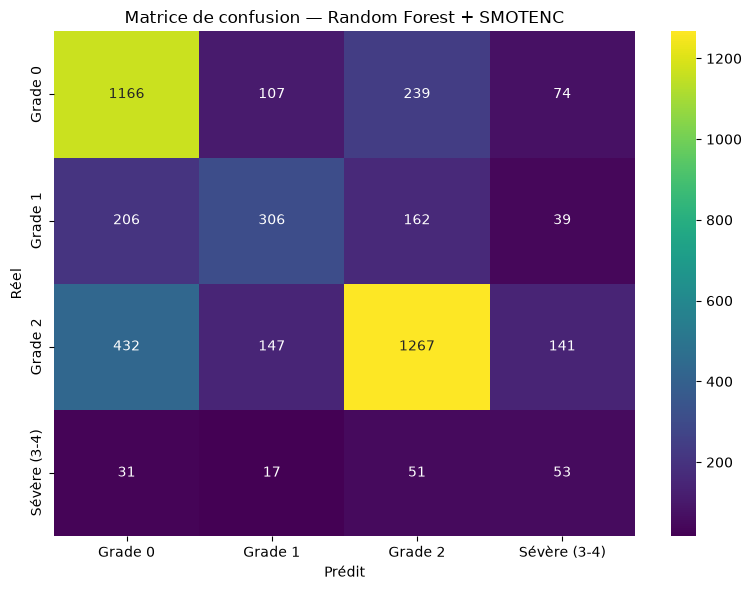

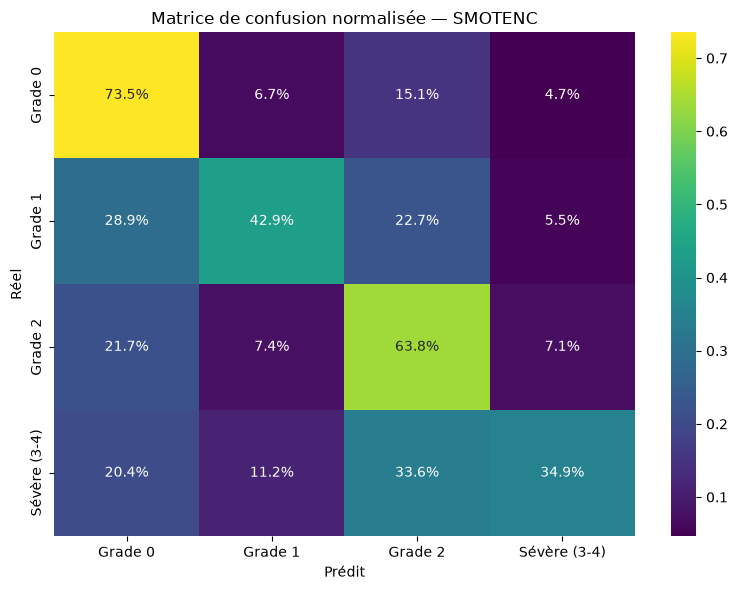

In [8]:
classes_finales = ['Grade 0', 'Grade 1', 'Grade 2', 'Sévère (3-4)']

cm = confusion_matrix(y_test_f, y_pred_smotenc, labels=classes_finales)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
            xticklabels=classes_finales, yticklabels=classes_finales)
plt.title("Matrice de confusion — Random Forest + SMOTENC")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.tight_layout()
plt.show()

# Version normalisée (% par ligne réelle) — plus lisible pour comparer les classes
cm_norm = confusion_matrix(y_test_f, y_pred_smotenc, labels=classes_finales, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='viridis',
            xticklabels=classes_finales, yticklabels=classes_finales)
plt.title("Matrice de confusion normalisée — SMOTENC")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.tight_layout()
plt.show()

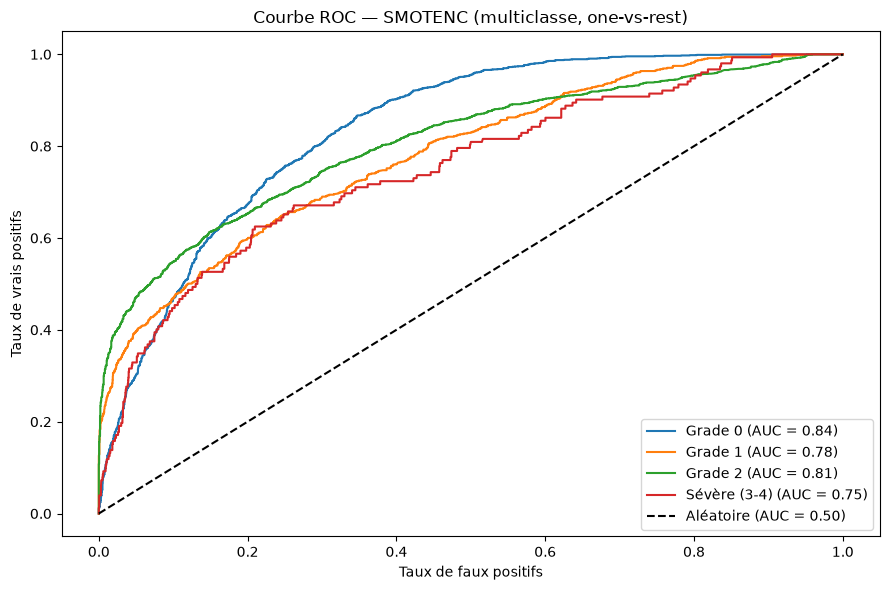

In [9]:
y_proba_smotenc = best_model_smotenc.predict_proba(X_test_brut)
classes_ordre = best_model_smotenc.named_steps['rf'].classes_

y_test_bin = label_binarize(y_test_f, classes=classes_finales)

plt.figure(figsize=(9, 6))
for i, grade in enumerate(classes_finales):
    idx = list(classes_ordre).index(grade)
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_smotenc[:, idx])
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{grade} (AUC = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire (AUC = 0.50)')
plt.title("Courbe ROC — SMOTENC (multiclasse, one-vs-rest)")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Seuil | Recall | Precision | F2-score
---------------------------------------------
 0.50 |  19.7%  |     18.2%  | 0.194
 0.40 |  32.9%  |     20.4%  | 0.293
 0.35 |  34.9%  |     17.0%  | 0.288
 0.30 |  40.1%  |     15.3%  | 0.303
 0.25 |  45.4%  |     13.5%  | 0.309
 0.20 |  52.6%  |     11.3%  | 0.303
 0.15 |  63.2%  |      8.6%  | 0.278
 0.10 |  72.4%  |      6.0%  | 0.226

Meilleur seuil : 0.25  →  F2 = 0.309


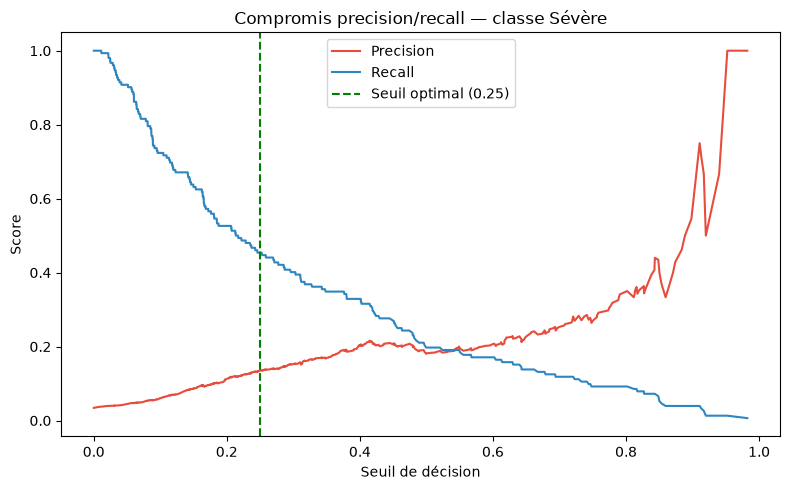

In [10]:
idx_severe = list(classes_ordre).index("Sévère (3-4)")
proba_severe_smotenc = y_proba_smotenc[:, idx_severe]
y_test_binaire_smotenc = (y_test_f == "Sévère (3-4)").astype(int)

precision_s, recall_s, seuils_s = precision_recall_curve(y_test_binaire_smotenc, proba_severe_smotenc)

print("Seuil | Recall | Precision | F2-score")
print("-" * 45)
meilleur_f2, meilleur_seuil = 0, 0
for seuil_test in [0.5, 0.4, 0.35, 0.3, 0.25, 0.2, 0.15, 0.1]:
    y_pred_seuil = (proba_severe_smotenc >= seuil_test).astype(int)
    f2 = fbeta_score(y_test_binaire_smotenc, y_pred_seuil, beta=2)
    tp = ((y_pred_seuil==1)&(y_test_binaire_smotenc==1)).sum()
    fp = ((y_pred_seuil==1)&(y_test_binaire_smotenc==0)).sum()
    fn = ((y_pred_seuil==0)&(y_test_binaire_smotenc==1)).sum()
    rec = tp/(tp+fn) if (tp+fn)>0 else 0
    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    print(f"{seuil_test:>5.2f} | {rec*100:>5.1f}%  | {prec*100:>8.1f}%  | {f2:.3f}")
    if f2 > meilleur_f2:
        meilleur_f2, meilleur_seuil = f2, seuil_test

print(f"\nMeilleur seuil : {meilleur_seuil}  →  F2 = {meilleur_f2:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(seuils_s, precision_s[:-1], label='Precision', color='#e74c3c')
plt.plot(seuils_s, recall_s[:-1], label='Recall', color='#2e86c1')
plt.axvline(x=meilleur_seuil, color='green', linestyle='--', label=f'Seuil optimal ({meilleur_seuil})')
plt.xlabel("Seuil de décision")
plt.ylabel("Score")
plt.title("Compromis precision/recall — classe Sévère")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
rf_model = best_model_smotenc.named_steps['rf']
encodeur_fit = best_model_smotenc.named_steps['encodeur']

X_test_sample_brut = X_test_brut.sample(n=200, random_state=42)
X_test_sample_encode = encodeur_fit.transform(X_test_sample_brut)

# >>> CORRECTION : convertir la matrice creuse en tableau dense avant de créer le DataFrame
if hasattr(X_test_sample_encode, "toarray"):
    X_test_sample_encode = X_test_sample_encode.toarray()

noms_colonnes_encodees = encodeur_fit.get_feature_names_out()

X_test_sample_df = pd.DataFrame(X_test_sample_encode, columns=noms_colonnes_encodees)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_sample_df)

print("Forme shap_values :", np.array(shap_values).shape)
print("Classes du modèle :", rf_model.classes_)

Forme shap_values : (200, 154, 4)
Classes du modèle : ['Grade 0' 'Grade 1' 'Grade 2' 'Sévère (3-4)']


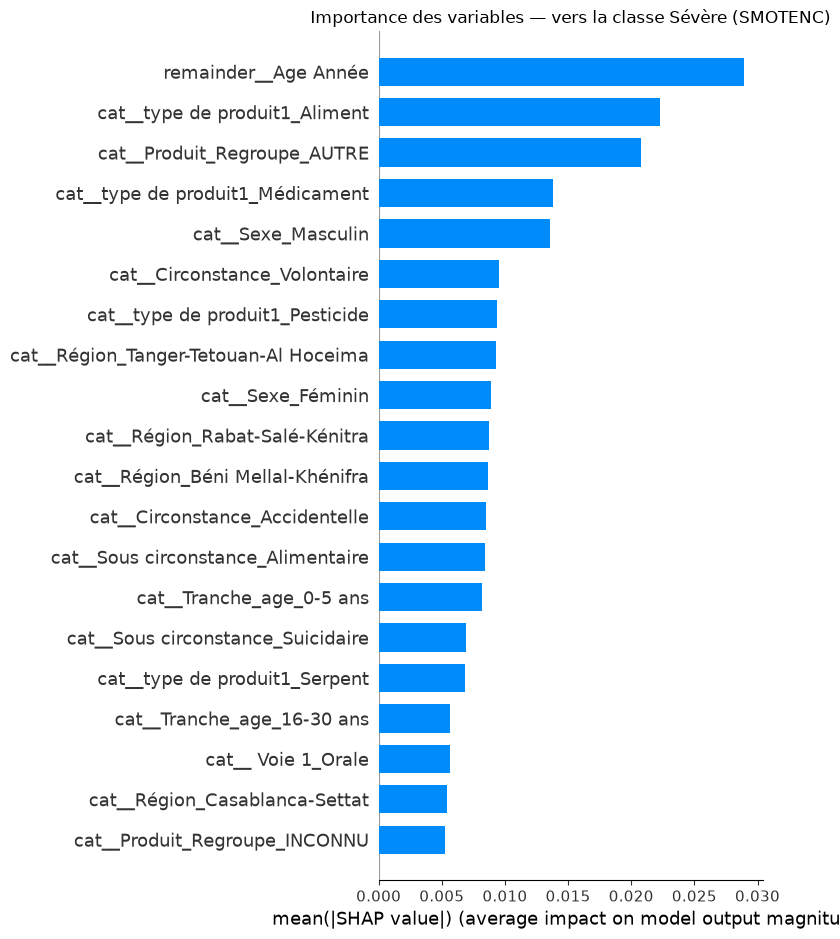

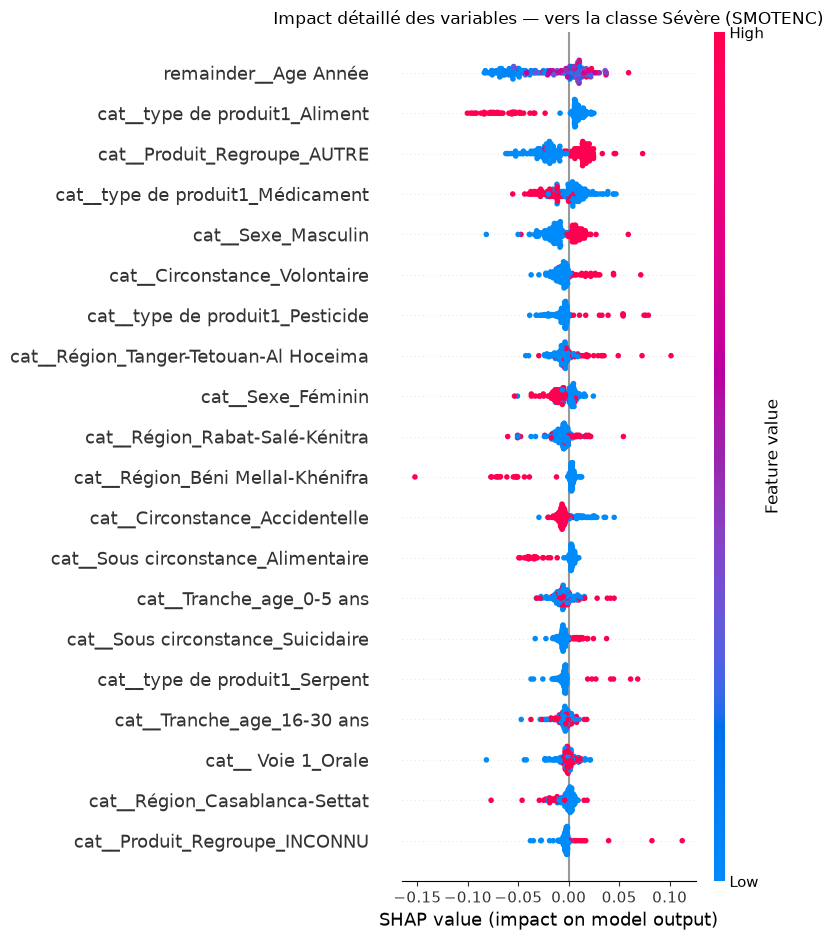

In [13]:
idx_severe_shap = list(rf_model.classes_).index("Sévère (3-4)")

# Si shap_values a la forme (n_lignes, n_features, n_classes) :
shap_severe = shap_values[:, :, idx_severe_shap]

shap.summary_plot(shap_severe, X_test_sample_df, plot_type="bar", show=False)
plt.title("Importance des variables — vers la classe Sévère (SMOTENC)")
plt.tight_layout()
plt.show()

shap.summary_plot(shap_severe, X_test_sample_df, show=False)
plt.title("Impact détaillé des variables — vers la classe Sévère (SMOTENC)")
plt.tight_layout()
plt.show()

In [14]:
os.makedirs("models_final", exist_ok=True)

joblib.dump(best_model_smotenc, "models_final/pipeline_randomforest_smotenc.pkl")
joblib.dump(X_brut.columns.tolist(), "models_final/colonnes_features.pkl")
joblib.dump(produits_frequents, "models_final/liste_produits_frequents.pkl")
joblib.dump(synonymes, "models_final/synonymes_produits.pkl")
joblib.dump(meilleur_seuil, "models_final/seuil_optimal_severe.pkl")

valeurs_categorielles = {
    col: sorted(df[col].dropna().unique().tolist())
    for col in ['Sexe', 'Milieu', 'Région', 'Circonstance', 'Sous circonstance',
                'type de produit1', ' Voie 1', 'Tranche_age']
}
joblib.dump(valeurs_categorielles, "models_final/valeurs_categorielles.pkl")

print("Tous les artefacts sauvegardés :", os.listdir("models_final"))

Tous les artefacts sauvegardés : ['colonnes_features.pkl', 'liste_produits_frequents.pkl', 'pipeline_randomforest_smotenc.pkl', 'seuil_optimal_severe.pkl', 'synonymes_produits.pkl', 'valeurs_categorielles.pkl']
